# 034 — Evaluation: the residual head and the `combined_loss` alpha sweep

Scores the three `unet_residual` checkpoints from `025_training_residual_head.ipynb`
against `unet` on the `data/test/` images, on the same axes as `040`/`C0`/`C3`:
reconstruction fidelity, detection AUROC against the hand-drawn masks, and
reference-free stroke coherence.

| column | checkpoint | alpha |
|---|---|---|
| `unet` | `models/deterministic/unet/` | 0.16 |
| `resid a=0.16` | `models/deterministic/unet_residual/` | 0.16 |
| `resid a=0.50` | `models/alpha_sweep/alpha_0.50/unet_residual/` | 0.50 |
| `resid a=0.84` | `models/alpha_sweep/alpha_0.84/unet_residual/` | 0.84 |

`unet` is the reference every delta is taken against: it shares the backbone and the
parameter count (31,037,633 both) with `unet_residual`, and at `alpha = 0.16` it shares
the loss too — so the `unet` vs. `resid a=0.16` pair isolates the **head**, and the three
`resid` columns isolate **alpha**.

**What the residual head does.** `unet` predicts IR directly through a sigmoid; `unet_residual`
predicts a signed `tanh` residual added to `mean(R, G, B)` and clipped back to `[0, 1]`
(`scripts/unet_residual.py`). The reference grey level is free, so the network only has to
learn where IR departs from it.

**The failure mode this notebook is built to catch.** A free identity path can be *ignored*
in two opposite ways, and neither shows up in `mae` alone:

- **collapse** — the residual goes to zero and the model becomes an expensive
  `mean(R, G, B)`. Nothing in the loss forbids it: the grey path already carries all of the
  RGB's structure, so an MS-SSIM-dominated loss is nearly satisfied by the identity.
- **saturation** — the residual is so large that the reference level is irrelevant and the
  `tanh`/clip pair fights the optimizer instead of helping it.

§4 measures both directly (`mean |mu - gray|`, clip occupancy) and §3 carries the control
that makes them readable: **`gray` — the parameter-free `mean(R, G, B)` baseline itself**.
Any model that does not beat that row has not earned its 31M parameters.

**What this notebook does not decide.** Detection AUROC rests on three masks, and across
`C0`+`C1` it correlates with *worse* reconstruction (Spearman `rho = +0.665`, `p = 0.005`
over 16 architecture x generation points). A column that wins §5 and loses §3 is not
obviously better — see `024` §6. Companion notebooks: `033` (the other `unet` variants),
`040`/`050` (signals, current generation), `025` (the training runs scored here).

Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports and a GPU sanity check. `scripts.trainer.load_model` is the deterministic
loader — importing it also registers `RGBToGray`/`ClipToUnitStraightThrough` (via
`scripts.unet_residual`), which the `unet_residual` checkpoints need to deserialize.

`keras` is printed because it matters here: `requirements.txt` pins `keras==3.15.1`, and
checkpoints saved by 3.15 **cannot be loaded by earlier versions** — the failure is a
confusing `HeNormal ... unexpected keyword argument 'input_axes'` deep inside
`Functional.from_config`, not a missing-file error.

In [2]:
import gc
from typing import NamedTuple

import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.detection import evaluate_detection
from scripts.stroke_stats import stroke_coherence
from scripts.trainer import load_model
from scripts.visualization_nll import plot_signal_comparison

print(f"keras {keras.__version__} | tensorflow {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

keras 3.15.1 | tensorflow 2.16.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. The `data/test/` images

Every `(rgb, ir)` pair under `data/test/`, discovered generically — same as `040`/`C0`/`C3`.
The three with a hand-drawn mask (`GT01`/`GT02`/`GT03`) additionally carry a detection
ground truth; fidelity and coherence need no mask and run on all of them.

`IMAGE_LIMIT` exists only to smoke-test the notebook end to end on a couple of images
before committing to the full pass; leave it at `None` for real numbers.

In [3]:
IMAGE_LIMIT: int | None = None  # -> 1 or 2 for a quick smoke test

TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR = project_root / "data" / "test" / "ir"
ANNOTATIONS_DIR = project_root / "data" / "test" / "annotations"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) + sorted(TEST_RGB_DIR.glob("*.png"))
image_pairs = [
    (p, TEST_IR_DIR / p.name)
    for p in sorted(rgb_paths)
    if (TEST_IR_DIR / p.name).exists()
]
gt_stems = {
    p.name.removesuffix("_Map.png") for p in sorted(ANNOTATIONS_DIR.glob("*_Map.png"))
}
gt_stems &= {p.stem for p, _ in image_pairs}

if IMAGE_LIMIT is not None:
    image_pairs = image_pairs[:IMAGE_LIMIT]
    gt_stems &= {p.stem for p, _ in image_pairs}
    print(f"[smoke test] limited to {len(image_pairs)} image(s)")

IR_PATHS = {p.stem: ir_path for p, ir_path in image_pairs}

print(f"data/test/ images: {len(image_pairs)} | {[p.stem for p, _ in image_pairs]}")
print(f"with a ground-truth mask: {sorted(gt_stems)}")

if not image_pairs:
    raise RuntimeError("No (rgb, ir) pairs found under data/test/.")

data/test/ images: 10 | ['GT01', 'GT02', 'GT03', 'bridge', 'case', 'face', 'green', 'modern', 'modern2', 'total']
with a ground-truth mask: ['GT01', 'GT02', 'GT03']


## 2. The runs, and where each checkpoint lives

A `Run` is one column: a label, the architecture, the directory holding it, and the alpha it
was trained at. `alpha` is carried explicitly because it does **not** survive into the
checkpoint — `025` passes it as `--loss-alpha` and only the launching command records it, so
this table is the single place the association is written down.

`load_model` recompiles with `loss_alpha`, which affects nothing computed here (every metric
below is derived from `predict`, not from `evaluate`), but keeping it right means a printed
`model.loss` is not misleading.

A missing checkpoint is skipped with a message, not an error.

In [4]:
DET_DIR = settings.MODELS_DIR / "deterministic"
SWEEP_DIR = settings.MODELS_DIR / "alpha_sweep"


class Run(NamedTuple):
    """One column of the comparison."""

    label: str
    arch: str
    model_dir: Path
    alpha: float


RUNS = [
    Run("unet", "unet", DET_DIR, settings.LOSS_ALPHA),
    Run("resid a=0.16", "unet_residual", DET_DIR, 0.16),
    Run("resid a=0.50", "unet_residual", SWEEP_DIR / "alpha_0.50", 0.50),
    Run("resid a=0.84", "unet_residual", SWEEP_DIR / "alpha_0.84", 0.84),
]
REFERENCE = "unet"
GRAY_LABEL = "gray"  # the parameter-free control of section 3
SIGNAL_KINDS = ("raw delta", "structural delta", "confidence")

def checkpoint_of(run: Run) -> Path:
    """Path of the checkpoint this run scores."""
    return run.model_dir / run.arch / "best_model.keras"


for run in RUNS:
    ckpt = checkpoint_of(run)
    state = "found" if ckpt.exists() else "MISSING"
    print(f"{run.label:<14} alpha={run.alpha:<5} {state:<8} {ckpt}")

missing = [r.label for r in RUNS if not checkpoint_of(r).exists()]
print(f"\nMissing (will be skipped): {missing or 'none'}")

unet           alpha=0.16  found    /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet/best_model.keras
resid a=0.16   alpha=0.16  found    /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet_residual/best_model.keras
resid a=0.50   alpha=0.5   found    /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.50/unet_residual/best_model.keras
resid a=0.84   alpha=0.84  found    /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.84/unet_residual/best_model.keras

Missing (will be skipped): none


## 3. Signals and diagnostics, per run

**Signals** — **raw delta**, **structural delta** and **confidence**, built exactly as in
`040`/`C0` from `analyze_delta`. These are deterministic checkpoints, so there is no sigma
and no `|z|`/`structural z` column (`041`/`C3` have those for the NLL family).

**Diagnostics** — two numbers per image that exist only for this architecture:

- `resid_l1 = mean |mu - gray|`: how far the prediction moves from the free reference level.
  Near zero means the head collapsed to the identity; the `unet` column is computed too,
  where it is not a diagnostic but a scale — how far a *working* direct-prediction model
  sits from grey.
- `clip_frac`: fraction of pixels pinned at exactly 0 or 1 by
  `ClipToUnitStraightThrough`. The clip is a straight-through estimator so these pixels
  still receive gradient, but a large fraction means the `tanh` residual is being asked to
  overshoot systematically. `unet`'s sigmoid never reaches the bounds, so its value is
  structurally 0 and not comparable — reported as `n/a`.

The `gray` control needs no model at all and is computed once, in the next cell.

In [5]:
MASK_THRESHOLD = 127  # midpoint threshold for the mask's anti-aliased edges
CLIP_EPS = 1e-6


def load_pair(rgb_path: Path, ir_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load an ``(rgb, ir)`` pair as float arrays in ``[0, 1]``."""
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0
    return rgb, ir


def load_mask(stem: str) -> np.ndarray:
    """Load a hand-drawn ground-truth mask as a boolean array."""
    mask_path = ANNOTATIONS_DIR / f"{stem}_Map.png"
    return np.array(Image.open(mask_path).convert("L")) > MASK_THRESHOLD


def load_ir(stem: str) -> np.ndarray:
    """Load one real IR image by stem, as a float array in ``[0, 1]``."""
    return np.array(Image.open(IR_PATHS[stem]).convert("L")).astype(np.float32) / 255.0


def fidelity(ir: np.ndarray, mu: np.ndarray) -> dict[str, float]:
    """MAE/SSIM/PSNR of a prediction against the real IR, as in 030."""
    real = tf.constant(ir[..., np.newaxis])
    pred = tf.constant(mu[..., np.newaxis])
    return {
        "mae": float(np.mean(np.abs(ir - mu))),
        "ssim": float(tf.image.ssim(real, pred, max_val=1.0)),
        "psnr": float(tf.image.psnr(real, pred, max_val=1.0)),
    }


def predict_mu(
    model: tf.keras.Model, rgb: np.ndarray, shape: tuple[int, int]
) -> np.ndarray:
    """Predict the single-channel IR for one full image."""
    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    h, w = shape
    return model.predict(padded[tf.newaxis, ...], verbose=0)[0, :h, :w, 0]


def build_signals(ir: np.ndarray, mu: np.ndarray) -> dict[str, np.ndarray]:
    """The three deterministic delta signals, as in 040."""
    result = analyze_delta(ir, mu)
    return {
        "raw delta": result.raw_delta,
        "structural delta": result.structural_delta,
        "confidence": result.confidence_map,
    }


def diagnostics(mu: np.ndarray, gray: np.ndarray) -> dict[str, float]:
    """Residual magnitude and clip occupancy — see the markdown above."""
    return {
        "resid_l1": float(np.mean(np.abs(mu - gray))),
        "clip_frac": float(np.mean((mu <= CLIP_EPS) | (mu >= 1.0 - CLIP_EPS))),
    }

### The `gray` control

`mean(R, G, B)` scored as if it were a model. This is the row every column in §3 has to
beat: it is what `unet_residual` outputs when its residual is zero, and it costs no
parameters, no training and no GPU.

It also answers the design question behind the head directly — how good an IR prior the
visible grey level actually is on these paintings.

In [6]:
gray_fidelity: dict[str, list[float]] = {}
gray_coherence: dict[str, list[float]] = {}
gray_auroc: dict[str, dict[str, float]] = {}

for rgb_path, ir_path in image_pairs:
    stem = rgb_path.stem
    rgb, ir = load_pair(rgb_path, ir_path)
    gray = rgb.mean(axis=-1)

    for metric, value in fidelity(ir, gray).items():
        gray_fidelity.setdefault(metric, []).append(value)

    for kind, signal in build_signals(ir, gray).items():
        gray_coherence.setdefault(kind, []).append(stroke_coherence(signal).coherence)
        if stem in gt_stems:
            detection = evaluate_detection(signal, load_mask(stem))
            gray_auroc.setdefault(kind, {})[stem] = detection.auroc

    print(f"  {stem}: gray control scored")
    del rgb, ir, gray

print("\ngray baseline (mean over all images):")
for metric, values in gray_fidelity.items():
    print(f"  {metric:<6} {np.mean(values):.4f}")

2026-08-28 09:12:47.337798: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-28 09:12:47.337829: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-28 09:12:47.337835: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-28 09:12:47.337852: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 09:12:47.337864: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


  GT01: gray control scored
  GT02: gray control scored
  GT03: gray control scored
  bridge: gray control scored
  case: gray control scored
  face: gray control scored
  green: gray control scored
  modern: gray control scored
  modern2: gray control scored
  total: gray control scored

gray baseline (mean over all images):
  mae    0.1381
  ssim   0.4975
  psnr   15.6389


## 4. The pass

One run at a time: load, score every `data/test/` image, release before the next — the
checkpoints are ~370 MB each, so holding four at once is avoidable memory pressure (same
handling as `C0`/`C3`).

`PLOT_IMAGES`/`PLOT_SIGNALS` control only the figures in §7; the tables always cover every
image and signal.

In [7]:
PLOT_IMAGES = set(gt_stems)  # -> {p.stem for p, _ in image_pairs} for all of them
PLOT_SIGNALS = {"structural delta"}

fidelity_rows: dict[str, dict[str, list[float]]] = {}
diagnostic_rows: dict[str, dict[str, list[float]]] = {}
coherence_rows: dict[tuple[str, str], list[float]] = {}
auroc_rows: dict[tuple[str, str], dict[str, float]] = {}
ap_rows: dict[tuple[str, str], dict[str, float]] = {}
signal_gallery: dict[tuple[str, str], dict[str, np.ndarray]] = {}

compared: list[str] = []

for run in RUNS:
    try:
        model = load_model(run.arch, model_dir=run.model_dir, loss_alpha=run.alpha)
    except FileNotFoundError as exc:
        print(f"[skip] {run.label}: {exc}")
        continue

    compared.append(run.label)
    print(f"\n=== {run.label} ({run.arch}, alpha={run.alpha}) ===")

    for rgb_path, ir_path in image_pairs:
        stem = rgb_path.stem
        rgb, ir = load_pair(rgb_path, ir_path)
        gray = rgb.mean(axis=-1)

        mu = predict_mu(model, rgb, ir.shape)
        signals = build_signals(ir, mu)

        for metric, value in fidelity(ir, mu).items():
            fidelity_rows.setdefault(run.label, {}).setdefault(metric, []).append(value)
        for metric, value in diagnostics(mu, gray).items():
            diags = diagnostic_rows.setdefault(run.label, {})
            diags.setdefault(metric, []).append(value)

        mask = load_mask(stem) if stem in gt_stems else None
        for kind, signal in signals.items():
            coherence_rows.setdefault((run.label, kind), []).append(
                stroke_coherence(signal).coherence
            )
            if mask is not None:
                detection = evaluate_detection(signal, mask)
                auroc_rows.setdefault((run.label, kind), {})[stem] = detection.auroc
                ap_row = ap_rows.setdefault((run.label, kind), {})
                ap_row[stem] = detection.average_precision

        for kind in PLOT_SIGNALS & set(signals):
            if stem in PLOT_IMAGES:
                signal_gallery.setdefault((stem, kind), {})[run.label] = signals[kind]

        print(f"  {stem}: scored")
        del rgb, ir, gray, mu, signals, mask

    del model
    gc.collect()
    tf.keras.backend.clear_session()

print(f"\nCompared: {compared}")
if REFERENCE not in compared:
    raise RuntimeError(
        f"The '{REFERENCE}' reference has no checkpoint — nothing to compare against."
    )


=== unet (unet, alpha=0.16) ===


2026-08-28 09:13:22.195368: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  GT01: scored
  GT02: scored
  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

=== resid a=0.16 (unet_residual, alpha=0.16) ===
  GT01: scored
  GT02: scored
  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

=== resid a=0.50 (unet_residual, alpha=0.5) ===
  GT01: scored
  GT02: scored
  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

=== resid a=0.84 (unet_residual, alpha=0.84) ===
  GT01: scored
  GT02: scored
  GT03: scored
  bridge: scored
  case: scored
  face: scored
  green: scored
  modern: scored
  modern2: scored
  total: scored

Compared: ['unet', 'resid a=0.16', 'resid a=0.50', 'resid a=0.84']


## 5. Reconstruction fidelity

`mae`/`ssim`/`psnr` of the prediction against the real IR, averaged over every `data/test/`
image — the axis `030`/`033` report. The parenthesised delta is against `unet`, oriented so
**positive always means improvement**.

The `gray` row is the parameter-free control, not a run: read every column against it first.
`unet` and `resid a=0.16` were trained with the *same* loss, so that pair is the clean read
on the head; the other two columns also change alpha.

In [8]:
LOWER_IS_BETTER = {"mae": True, "ssim": False, "psnr": False}


def gain(metric: str, ref: float, other: float) -> float:
    """Signed improvement of ``other`` over ``ref``, positive = better."""
    return ref - other if LOWER_IS_BETTER[metric] else other - ref


col_w = 22
header = "metric".ljust(10) + GRAY_LABEL.rjust(col_w)
for label in compared:
    header += label.rjust(col_w)
print(header)
print("-" * len(header))

for metric in LOWER_IS_BETTER:
    row = metric.ljust(10) + f"{np.mean(gray_fidelity[metric]):.4f}".rjust(col_w)
    ref_value = float(np.mean(fidelity_rows[REFERENCE][metric]))
    for label in compared:
        value = float(np.mean(fidelity_rows[label][metric]))
        delta = gain(metric, ref_value, value)
        marker = "" if label == REFERENCE else f" ({delta:+.4f})"
        row += f"{value:.4f}{marker}".rjust(col_w)
    print(row)

print(f"\n(mean over {len(image_pairs)} data/test/ images; "
      f"parenthesised delta vs. {REFERENCE}, positive = improvement)")

metric                      gray                  unet          resid a=0.16          resid a=0.50          resid a=0.84
------------------------------------------------------------------------------------------------------------------------
mae                       0.1381                0.1265      0.1397 (-0.0131)      0.0982 (+0.0284)      0.0980 (+0.0285)
ssim                      0.4975                0.6071      0.4951 (-0.1120)      0.5085 (-0.0986)      0.5085 (-0.0986)
psnr                     15.6389               16.6486     15.5552 (-1.0935)     18.2496 (+1.6009)     18.2951 (+1.6464)

(mean over 10 data/test/ images; parenthesised delta vs. unet, positive = improvement)


## 6. Residual-head diagnostics — did the head actually get used?

`resid_l1 = mean |mu - gray|` is the magnitude of the learned residual. Read it against the
`mae` row of §5:

- **`resid_l1` ≈ 0 and `mae` ≈ `gray`'s `mae`** — the head **collapsed**. The model is an
  expensive `mean(R, G, B)`: 31M parameters and a full training run producing what one
  `numpy` call produces. This is a training outcome, not a bug in the architecture, and the
  loss is the first suspect — a free identity path already satisfies most of an
  MS-SSIM-dominated objective, so at low alpha there is little gradient pressure to build a
  real residual.
- **`resid_l1` comparable to `unet`'s** — the head is being used as intended.
- **`clip_frac` large** — the residual is systematically overshooting the valid range. The
  straight-through clip keeps those pixels learning, but it is a sign the `tanh` range is
  being fought rather than used.

`unet`'s own `resid_l1` is the scale to calibrate against: it is what a working
direct-prediction model happens to sit away from grey, with no residual parameterization at
all. Its `clip_frac` is structurally 0 (sigmoid never reaches its asymptotes) and is
reported as `n/a` rather than as a win.

In [9]:
DIAG_KEYS = ("resid_l1", "clip_frac")

col_w = 16
header = "diagnostic".ljust(14)
for label in compared:
    header += label.rjust(col_w)
print(header)
print("-" * len(header))

for metric in DIAG_KEYS:
    row = metric.ljust(14)
    for label in compared:
        value = float(np.mean(diagnostic_rows[label][metric]))
        cell = "n/a" if metric == "clip_frac" and label == REFERENCE else f"{value:.4f}"
        row += cell.rjust(col_w)
    print(row)

COLLAPSE_THRESHOLD = 0.01  # mean |mu - gray| below this is indistinguishable from grey

print()
gray_mae = float(np.mean(gray_fidelity["mae"]))
for label in compared:
    resid_l1 = float(np.mean(diagnostic_rows[label]["resid_l1"]))
    mae = float(np.mean(fidelity_rows[label]["mae"]))
    if resid_l1 < COLLAPSE_THRESHOLD:
        verdict = "COLLAPSED to gray — see the markdown above"
    else:
        against_gray = "beats" if mae < gray_mae else "LOSES TO"
        verdict = f"residual in use, mae {against_gray} the gray control"
    print(f"{label:<14} {verdict}")

diagnostic                unet    resid a=0.16    resid a=0.50    resid a=0.84
------------------------------------------------------------------------------
resid_l1                0.0887          0.0027          0.1030          0.1102
clip_frac                  n/a          0.0000          0.0003          0.0004

unet           residual in use, mae beats the gray control
resid a=0.16   COLLAPSED to gray — see the markdown above
resid a=0.50   residual in use, mae beats the gray control
resid a=0.84   residual in use, mae beats the gray control


## 7. Detection — read with `024` §6's confound in mind

AUROC and average precision of each signal against the hand-drawn masks, averaged over
`GT01`/`GT02`/`GT03` only. `0.5` is chance. The `gray` control appears here too: a signal
built from the *grey image itself* still produces a delta against the real IR, and any model
whose AUROC does not beat that has added nothing to detection.

With `n = 3` the mean hides a lot, so the per-image breakdown follows.

In [10]:
def detection_table(rows: dict[tuple[str, str], dict[str, float]],
                    gray_rows: dict[str, dict[str, float]] | None,
                    label: str) -> None:
    """Signal x run table of a per-image detection metric, averaged over the masks."""
    name_w = 20
    col_w = 16
    header = "signal".ljust(name_w)
    if gray_rows is not None:
        header += GRAY_LABEL.rjust(col_w)
    for run_label in compared:
        header += run_label.rjust(col_w)
    print(header)
    print("-" * len(header))
    for kind in SIGNAL_KINDS:
        if not all((run_label, kind) in rows for run_label in compared):
            continue
        row = kind.ljust(name_w)
        if gray_rows is not None:
            row += f"{np.mean(list(gray_rows[kind].values())):.4f}".rjust(col_w)
        for run_label in compared:
            row += f"{np.mean(list(rows[(run_label, kind)].values())):.4f}".rjust(col_w)
        print(row)
    print(f"\n({label}, mean over {sorted(gt_stems)})")


if auroc_rows:
    print("AUROC\n")
    detection_table(auroc_rows, gray_auroc, "AUROC")
    print("\n\naverage precision\n")
    detection_table(ap_rows, None, "average precision")
else:
    print("No ground-truth mask found under data/test/annotations/ — section skipped.")

AUROC

signal                          gray            unet    resid a=0.16    resid a=0.50    resid a=0.84
----------------------------------------------------------------------------------------------------
raw delta                     0.4434          0.4726          0.4429          0.4901          0.4972
structural delta              0.6702          0.7073          0.6707          0.6700          0.6700
confidence                    0.4062          0.5193          0.4023          0.3577          0.3577

(AUROC, mean over ['GT01', 'GT02', 'GT03'])


average precision

signal                          unet    resid a=0.16    resid a=0.50    resid a=0.84
------------------------------------------------------------------------------------
raw delta                     0.0244          0.0163          0.0355          0.0395
structural delta              0.0676          0.0558          0.0557          0.0557
confidence                    0.0180          0.0149          0.0142          0.01

### Per-image AUROC breakdown

The `n = 3` mean above can be carried entirely by one favourable image.

In [11]:
if auroc_rows:
    stems = sorted(gt_stems)
    name_w = 20
    header = "signal".ljust(name_w)
    for stem in stems:
        for label in compared:
            header += f"{stem}/{label.replace('resid ', '')}".rjust(16)
    print(header)
    print("-" * len(header))
    for kind in SIGNAL_KINDS:
        if not all((label, kind) in auroc_rows for label in compared):
            continue
        row = kind.ljust(name_w)
        for stem in stems:
            for label in compared:
                row += f"{auroc_rows[(label, kind)][stem]:.3f}".rjust(16)
        print(row)
else:
    print("No ground-truth mask found — section skipped.")

signal                     GT01/unet     GT01/a=0.16     GT01/a=0.50     GT01/a=0.84       GT02/unet     GT02/a=0.16     GT02/a=0.50     GT02/a=0.84       GT03/unet     GT03/a=0.16     GT03/a=0.50     GT03/a=0.84
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
raw delta                      0.442           0.360           0.631           0.646           0.461           0.524           0.401           0.401           0.515           0.445           0.438           0.445
structural delta               0.815           0.722           0.719           0.719           0.662           0.626           0.628           0.628           0.645           0.665           0.663           0.663
confidence                     0.509           0.369           0.365           0.366           0.488           0.435           0.418           0.418

## 8. Stroke coherence — the reference-free corroboration

How much of each signal is oriented, line-like structure rather than isotropic noise
(`scripts.stroke_stats`). No mask needed, so it runs on every `data/test/` image and is a
structurally independent check on §7's ranking — which matters here, because §7 rests on
three masks.

In [12]:
name_w = 20
col_w = 18
header = "signal".ljust(name_w) + GRAY_LABEL.rjust(col_w)
for label in compared:
    header += label.rjust(col_w)
print(header)
print("-" * len(header))

for kind in SIGNAL_KINDS:
    if not all((label, kind) in coherence_rows for label in compared):
        continue
    row = kind.ljust(name_w)
    gray_values = np.array(gray_coherence[kind])
    row += f"{gray_values.mean():.3f}±{gray_values.std():.3f}".rjust(col_w)
    for label in compared:
        values = np.array(coherence_rows[(label, kind)])
        row += f"{values.mean():.3f}±{values.std():.3f}".rjust(col_w)
    print(row)

print(f"\n(mean ± std over {len(image_pairs)} data/test/ images)")

signal                            gray              unet      resid a=0.16      resid a=0.50      resid a=0.84
--------------------------------------------------------------------------------------------------------------
raw delta                  0.230±0.055       0.244±0.069       0.231±0.054       0.224±0.066       0.225±0.067
structural delta           0.277±0.043       0.357±0.065       0.278±0.042       0.277±0.043       0.277±0.043
confidence                 0.281±0.059       0.338±0.069       0.282±0.060       0.282±0.044       0.282±0.044

(mean ± std over 10 data/test/ images)


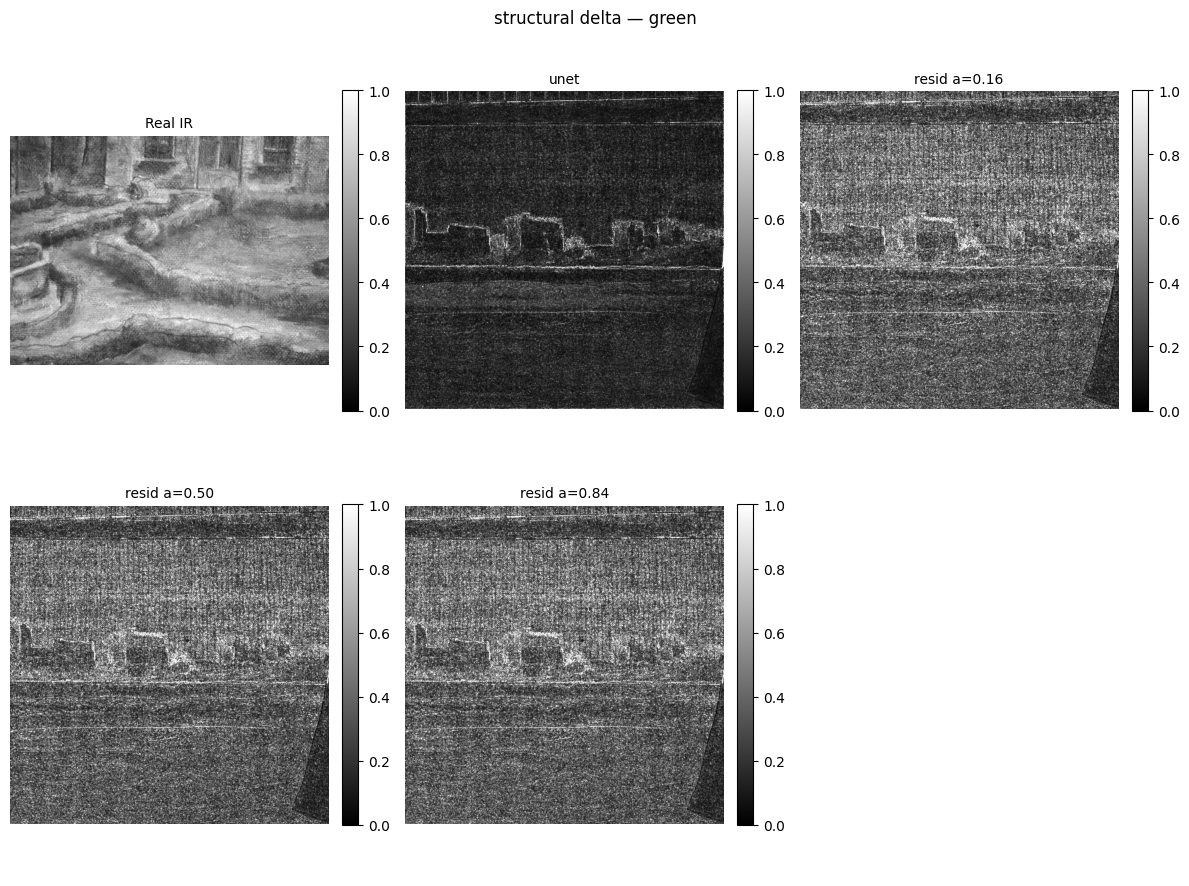

In [20]:
fig = plot_signal_comparison(
    load_ir('green'),
    signals,
    title=f"{'structural delta'} — {'green'}",
    vrange=(0.0, 1.0),
)
plt.show()
plt.close(fig)

if not signal_gallery:
    print("PLOT_IMAGES / PLOT_SIGNALS selected nothing — no figures.")

## 9. Figures — the signals side by side

One figure per (ground-truth image, signal kind), all runs in the same panel row against the
real IR. A collapsed column looks like the `gray` control's own delta, which is the visual
form of §6's number.

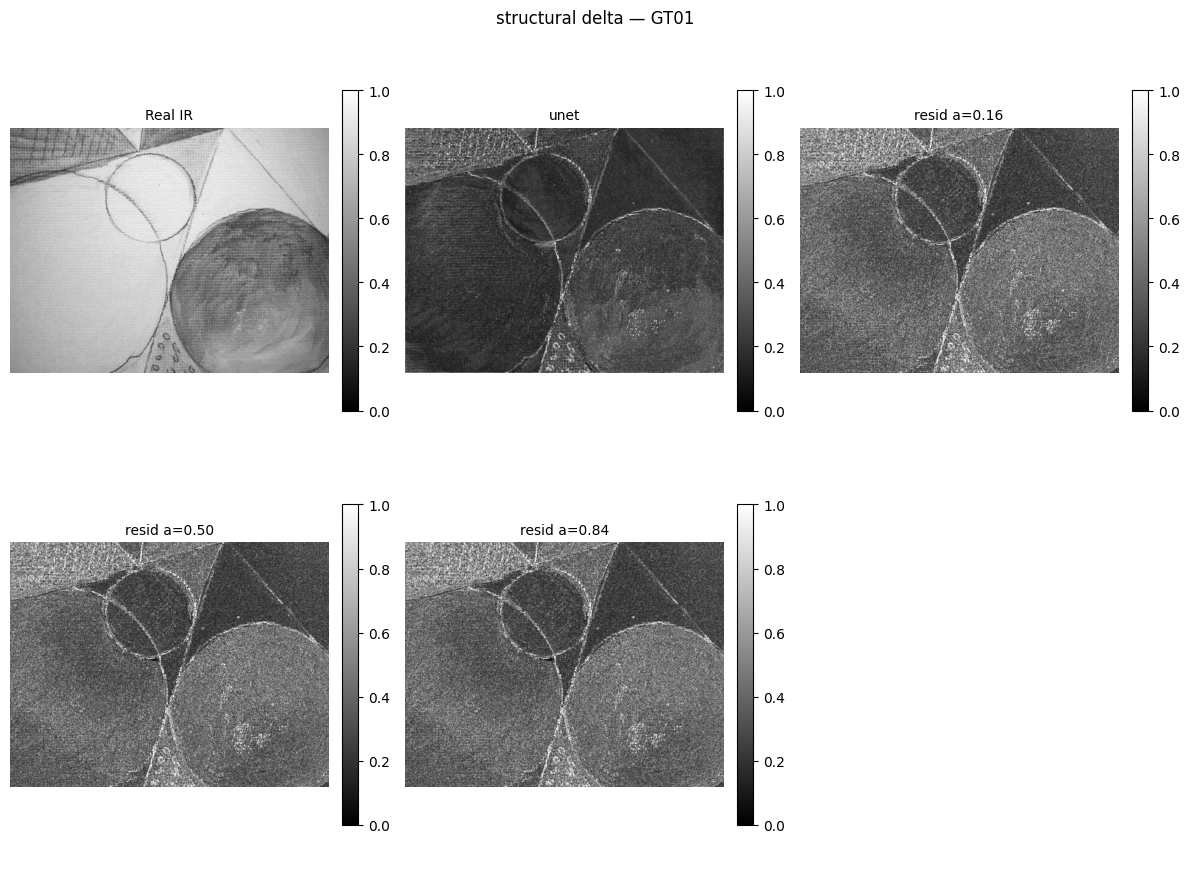

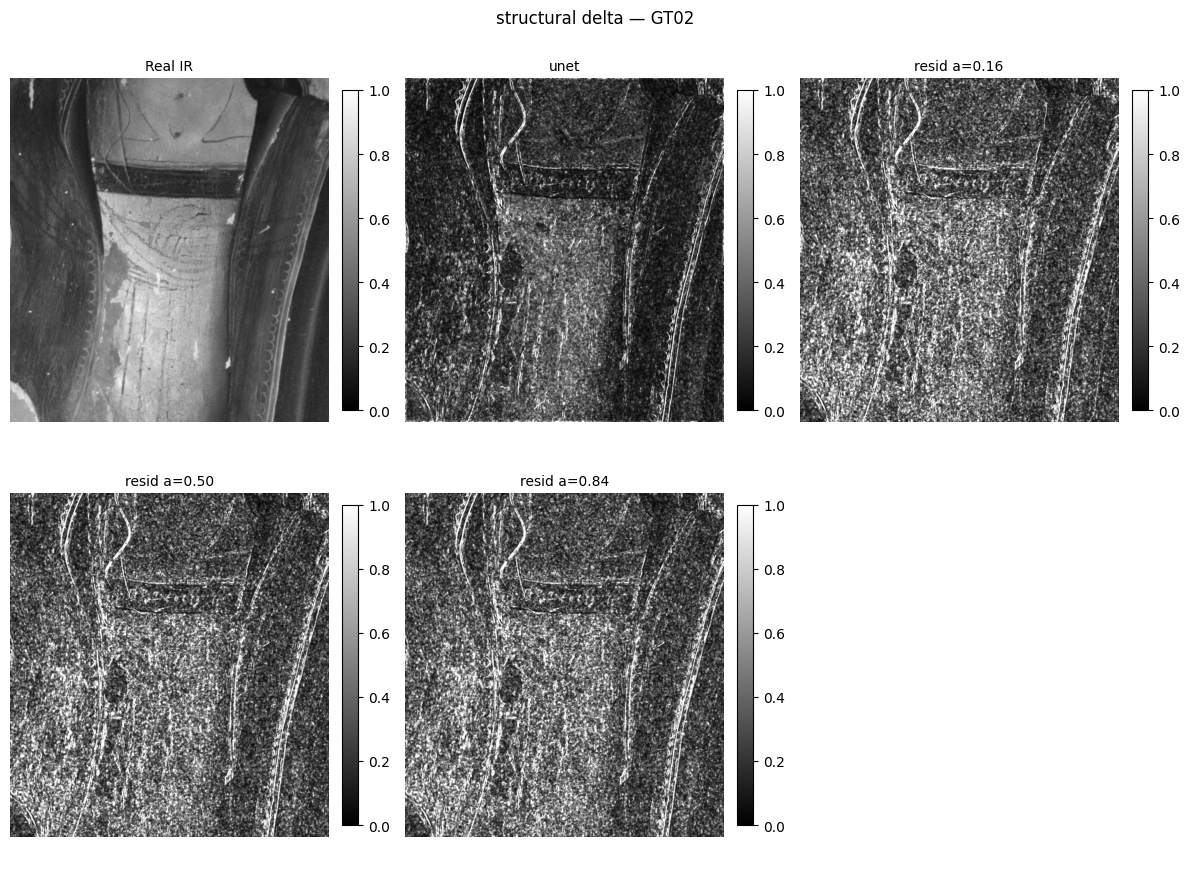

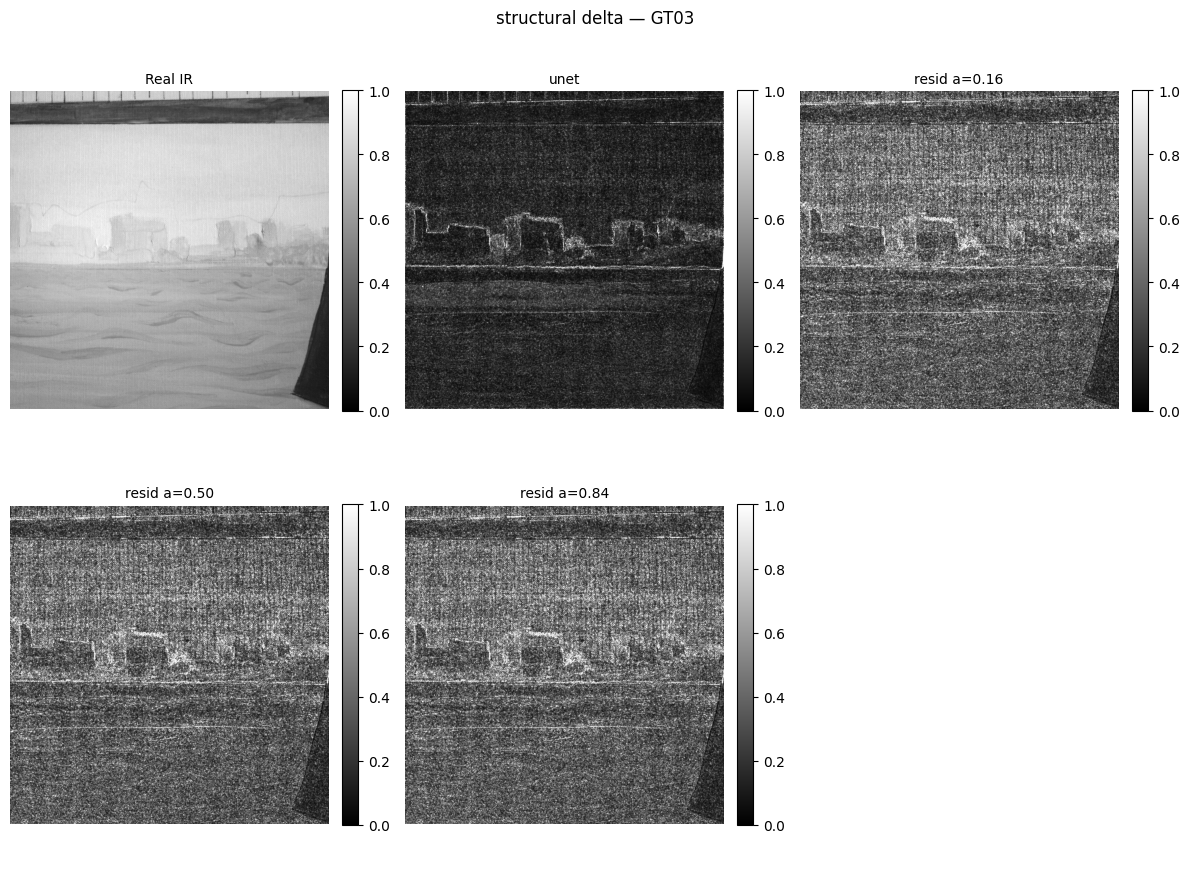

In [13]:
for (stem, kind), signals in sorted(signal_gallery.items()):
    fig = plot_signal_comparison(
        load_ir(stem),
        signals,
        title=f"{kind} — {stem}",
        vrange=(0.0, 1.0),
    )
    plt.show()
    plt.close(fig)

if not signal_gallery:
    print("PLOT_IMAGES / PLOT_SIGNALS selected nothing — no figures.")

## 10. Verdict

`k/n` counts how many measures in each group improve on `unet`: fidelity over
`mae`/`ssim`/`psnr`, detection over the three signals' mean AUROC, coherence over the three
signals' mean coherence. `beats gray` is the honest floor — a column that fails it did not
earn its parameters, whatever the deltas say.

This is a tally, not a decision. A column that wins detection while losing fidelity is
exactly the `C0`+`C1` confound (`024` §6), and a collapsed column can score respectably on
signals derived from a delta that is really the grey image's delta.

In [14]:
def tally(gains: list[float]) -> str:
    """``"k/n"`` — how many of these gains are improvements over the reference."""
    if not gains:
        return "-"
    return f"{sum(g > 0 for g in gains)}/{len(gains)}"


name_w = 14
print(
    "run".ljust(name_w)
    + "fidelity".rjust(11)
    + "detection".rjust(11)
    + "coherence".rjust(11)
    + "beats gray".rjust(12)
    + "resid_l1".rjust(11)
)
print("-" * (name_w + 56))

for label in compared:
    mae = float(np.mean(fidelity_rows[label]["mae"]))
    beats_gray = "yes" if mae < gray_mae else "NO"
    resid_l1 = float(np.mean(diagnostic_rows[label]["resid_l1"]))

    if label == REFERENCE:
        cells = "(reference)".rjust(33)
    else:
        fidelity_gains = [
            gain(
                metric,
                float(np.mean(fidelity_rows[REFERENCE][metric])),
                float(np.mean(fidelity_rows[label][metric])),
            )
            for metric in LOWER_IS_BETTER
        ]
        detection_gains = [
            float(np.mean(list(auroc_rows[(label, kind)].values())))
            - float(np.mean(list(auroc_rows[(REFERENCE, kind)].values())))
            for kind in SIGNAL_KINDS
            if (label, kind) in auroc_rows and (REFERENCE, kind) in auroc_rows
        ]
        coherence_gains = [
            float(np.mean(coherence_rows[(label, kind)]))
            - float(np.mean(coherence_rows[(REFERENCE, kind)]))
            for kind in SIGNAL_KINDS
            if (label, kind) in coherence_rows and (REFERENCE, kind) in coherence_rows
        ]
        cells = (
            tally(fidelity_gains).rjust(11)
            + tally(detection_gains).rjust(11)
            + tally(coherence_gains).rjust(11)
        )

    print(
        label.ljust(name_w)
        + cells
        + beats_gray.rjust(12)
        + f"{resid_l1:.4f}".rjust(11)
    )

print(f"\n(k/n better than {REFERENCE}; 'beats gray' compares mae against the "
      f"parameter-free mean(R,G,B) control)")

run              fidelity  detection  coherence  beats gray   resid_l1
----------------------------------------------------------------------
unet                                (reference)         yes     0.0887
resid a=0.16          0/3        0/3        0/3          NO     0.0027
resid a=0.50          2/3        1/3        0/3         yes     0.1030
resid a=0.84          2/3        1/3        0/3         yes     0.1102

(k/n better than unet; 'beats gray' compares mae against the parameter-free mean(R,G,B) control)


## 11. One image on demand

§9 can only plot what §4 captured, and §4 captures only `PLOT_IMAGES x PLOT_SIGNALS` — it
discards each prediction as soon as it is scored, because holding ten full-resolution
predictions per run is what would actually exhaust memory. So to look at an image that was
not selected up front there are two routes:

- **cheap, if you have not run §4 yet**: add the stem to `PLOT_IMAGES` there
  (`PLOT_IMAGES = set(gt_stems) | {"green"}`) and §9 picks it up with no new code — the
  signals come from `signal_gallery[("green", "structural delta")]`.
- **cheap, if you already ran §4** and would rather not redo forty predictions: this cell.
  It re-loads each checkpoint and predicts **one** image, which is four model loads instead
  of four loads plus forty predictions.

`STEM` accepts any stem printed in §1, with or without a ground-truth mask — nothing here
needs one. `KIND` is any key of `SIGNAL_KINDS`.

  unet           mae=0.1211  ssim=0.6144  psnr=17.2518  resid_l1=0.0317  clip_frac=0.0000
  resid a=0.16   mae=0.1170  ssim=0.4676  psnr=17.2567  resid_l1=0.0024  clip_frac=0.0000
  resid a=0.50   mae=0.0872  ssim=0.4635  psnr=19.0656  resid_l1=0.1058  clip_frac=0.0003
  resid a=0.84   mae=0.0877  ssim=0.4627  psnr=18.9472  resid_l1=0.1131  clip_frac=0.0004


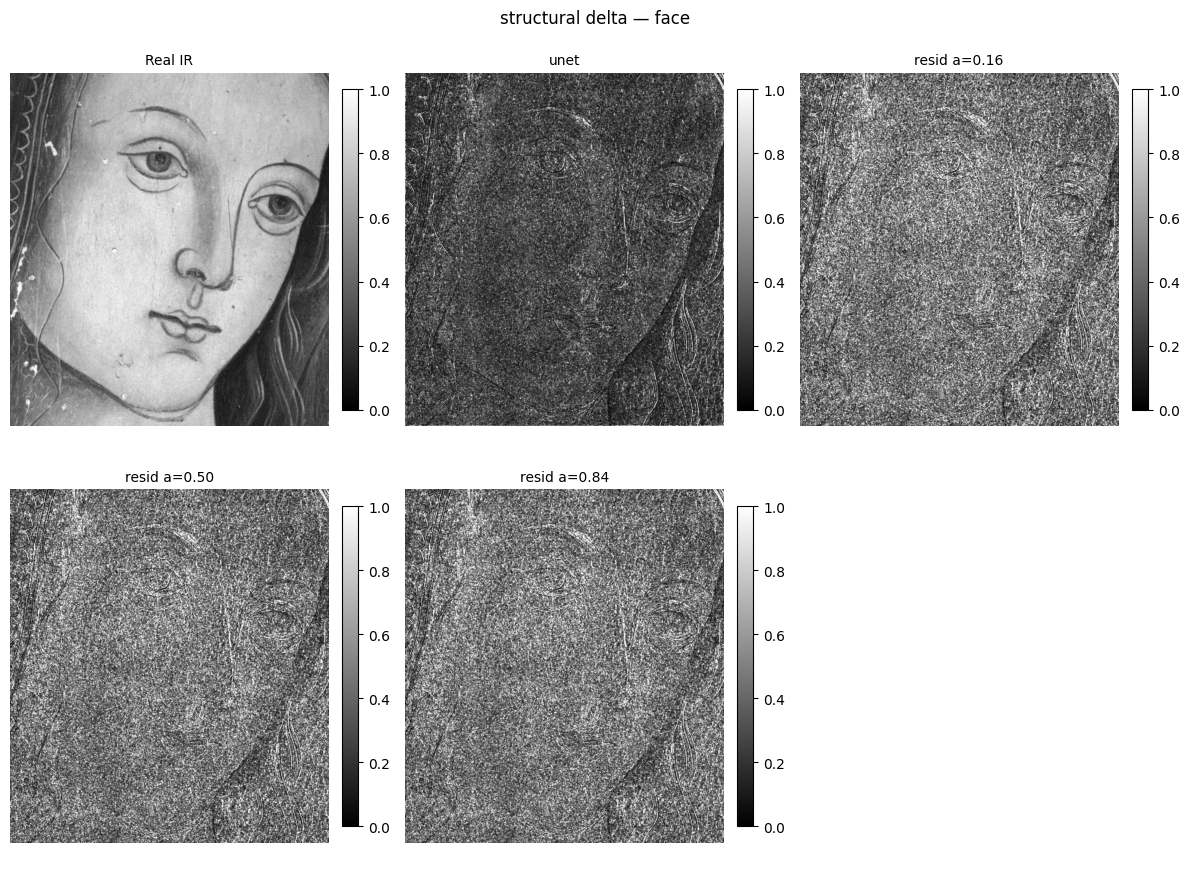

In [23]:
STEM = "face"
KIND = "structural delta"

rgb_path = next(p for p, _ in image_pairs if p.stem == STEM)
rgb, ir = load_pair(rgb_path, IR_PATHS[STEM])
one_image_signals: dict[str, np.ndarray] = {}

for run in RUNS:
    if not checkpoint_of(run).exists():
        print(f"[skip] {run.label}: no checkpoint")
        continue

    model = load_model(run.arch, model_dir=run.model_dir, loss_alpha=run.alpha)
    mu = predict_mu(model, rgb, ir.shape)
    one_image_signals[run.label] = build_signals(ir, mu)[KIND]

    scores = fidelity(ir, mu) | diagnostics(mu, rgb.mean(axis=-1))
    print(f"  {run.label:<14} " + "  ".join(f"{k}={v:.4f}" for k, v in scores.items()))

    del model, mu
    gc.collect()
    tf.keras.backend.clear_session()

fig = plot_signal_comparison(
    ir,
    one_image_signals,
    title=f"{KIND} — {STEM}",
    vrange=(0.0, 1.0),
)
plt.show()
plt.close(fig)

del rgb, ir